# Import Library

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, RobustScaler,MinMaxScaler,LabelEncoder,OneHotEncoder
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error as mse,r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor,ElasticNet

# Load data dan EDA

In [44]:
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Competition_s Files/Competition's Files/train_sample.csv")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Competition_s Files/Competition's Files/test_sample.csv")

In [45]:
df = df_train.copy()
df2 = df_test.copy()

In [46]:
df_filtered = df[
    (df['start_point'] == 'West Jakarta (Jakarta Barat)') &
    (df['end_point'] == 'North Jakarta (Jakarta Utara)')
]

print(df_filtered)
print(f"Jumlah baris ditemukan: {len(df_filtered)}")


Empty DataFrame
Columns: [start_point, end_point, time_of_day, day_of_week, traffic_condition, event_count, is_holiday, vehicle_density, population_density, weather, public_transport_availability, historical_delay_factor, travel_time]
Index: []
Jumlah baris ditemukan: 0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   start_point                    40000 non-null  object 
 1   end_point                      40000 non-null  object 
 2   time_of_day                    40000 non-null  object 
 3   day_of_week                    40000 non-null  object 
 4   traffic_condition              25599 non-null  float64
 5   event_count                    40000 non-null  int64  
 6   is_holiday                     40000 non-null  int64  
 7   vehicle_density                25622 non-null  object 
 8   population_density             25552 non-null  object 
 9   weather                        25571 non-null  object 
 10  public_transport_availability  40000 non-null  int64  
 11  historical_delay_factor        40000 non-null  float64
 12  travel_time                    40000 non-null 

In [48]:
df.head(5)

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor,travel_time
0,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),day,Sunday,NaN,9,1,NaN,high,NaN,1,0.878909,26.907612
1,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),morning,Thursday,NaN,7,1,medium,high,NaN,1,1.081668,27.489129
2,Central Jakarta (Jakarta Pusat),East Jakarta (Jakarta Timur),morning,Thursday,NaN,7,0,medium,low,NaN,2,1.192379,27.228978
3,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),morning,Friday,10.0,9,0,medium,high,fog,1,0.833348,33.943970
4,Central Jakarta (Jakarta Pusat),West Jakarta (Jakarta Barat),day,Tuesday,NaN,7,0,medium,high,rain,2,0.966819,20.603115


In [49]:
df.describe()

,traffic_condition,event_count,is_holiday,public_transport_availability,historical_delay_factor,travel_time
count,25599.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,8.455877,8.704900,0.500975,1.499525,1.009510,30.405411
std,1.829816,5.374108,0.500005,0.671201,0.162034,15.074854
min,3.000000,7.000000,0.000000,0.000000,0.750009,2.490207
25%,9.000000,7.000000,0.000000,1.000000,0.878415,18.685606
50%,9.000000,8.000000,1.000000,2.000000,1.003418,26.604213
75%,10.000000,9.000000,1.000000,2.000000,1.132044,39.771383
max,10.000000,88.000000,1.000000,2.000000,2.701010,218.832465


## Chech Cardinality Data

In [50]:
a = df['start_point'].value_counts()
b = df['end_point'].value_counts()
c = df['time_of_day'].value_counts()
d = df['day_of_week'].value_counts()
e = df['traffic_condition'].value_counts()
f = df['event_count'].value_counts()
g = df['is_holiday'].value_counts()
h = df['vehicle_density'].value_counts()
i = df['population_density'].value_counts()
j = df['weather'].value_counts()
k = df['public_transport_availability'].value_counts()
l = df['historical_delay_factor'].value_counts()


print(f"Kolom:",a)
print(f"Kolom:",b)
print(f"Kolom:",c)
print(f"Kolom:",d)
print(f"Kolom:",e)
print(f"Kolom:",f)
print(f"Kolom:",g)
print(f"Kolom:",h)
print(f"Kolom:",i)
print(f"Kolom:",j)
print(f"Kolom:",k)
print(f"Kolom:",l)

Kolom: start_point
Central Jakarta (Jakarta Pusat)    16120
North Jakarta (Jakarta Utara)      11893
West Jakarta (Jakarta Barat)        7974
South Jakarta (Jakarta Selatan)     4013
Name: count, dtype: int64
Kolom: end_point
East Jakarta (Jakarta Timur)       15874
South Jakarta (Jakarta Selatan)    11999
West Jakarta (Jakarta Barat)        8163
North Jakarta (Jakarta Utara)       3964
Name: count, dtype: int64
Kolom: time_of_day
night      10098
evening    10016
day         9978
morning     9908
Name: count, dtype: int64
Kolom: day_of_week
Monday       5781
Wednesday    5746
Thursday     5744
Friday       5711
Tuesday      5707
Saturday     5666
Sunday       5645
Name: count, dtype: int64
Kolom: traffic_condition
9.0     12390
10.0     7600
5.0      5033
7.0       291
8.0       179
3.0       106
Name: count, dtype: int64
Kolom: event_count
7     13186
8     13124
9     12984
48      266
49      218
47      218
87        2
88        2
Name: count, dtype: int64
Kolom: is_holiday
1    2

## Chech Missing Value

In [51]:
df.isnull().sum()

,0
start_point,0
end_point,0
time_of_day,0
day_of_week,0
traffic_condition,14401
event_count,0
is_holiday,0
vehicle_density,14378
population_density,14448
weather,14429


## Check distribution numerik columns

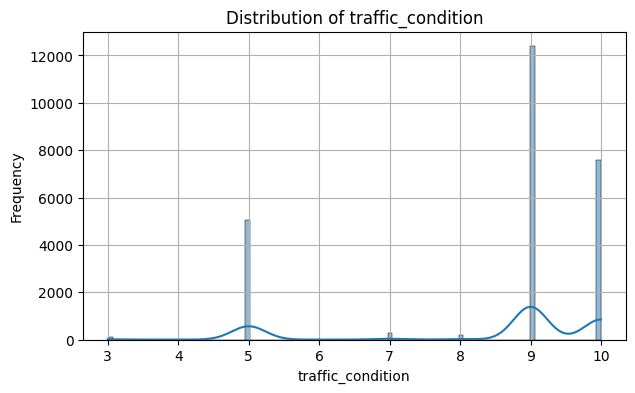

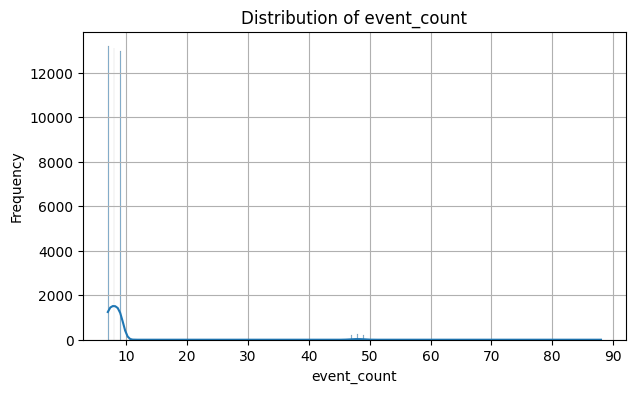

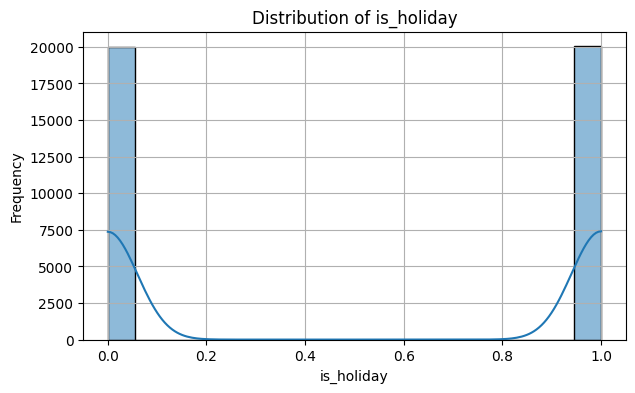

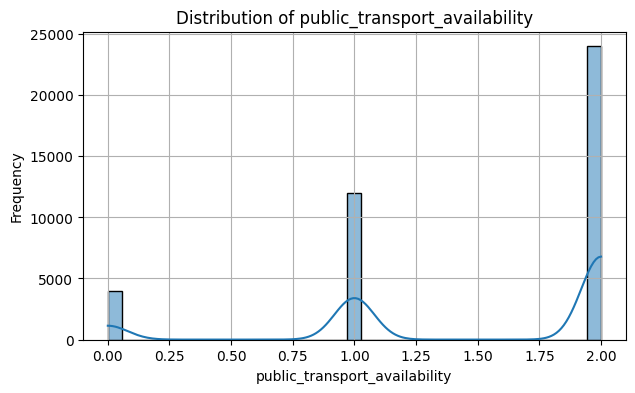

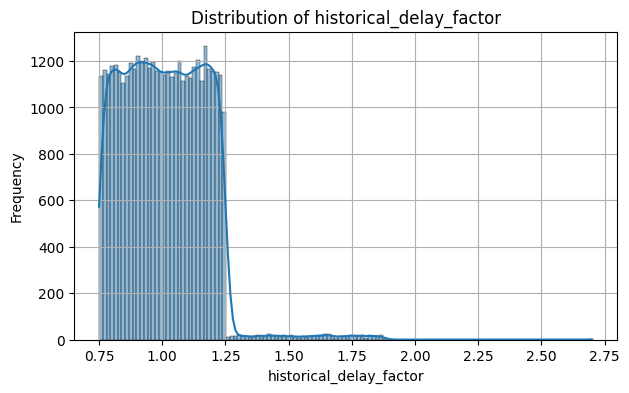

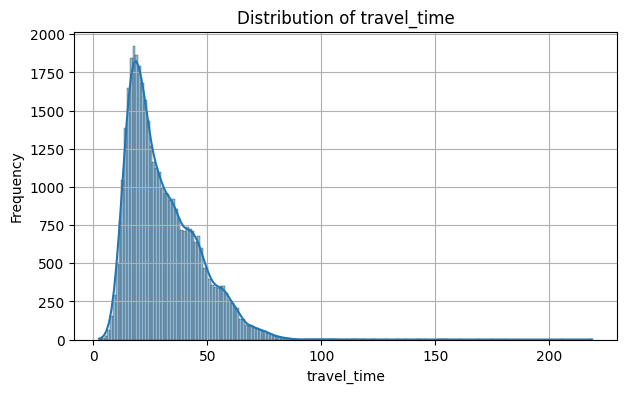

In [52]:
numeric_columns = df.select_dtypes(include=['number']).columns

for col in numeric_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

## Check distribution category columns

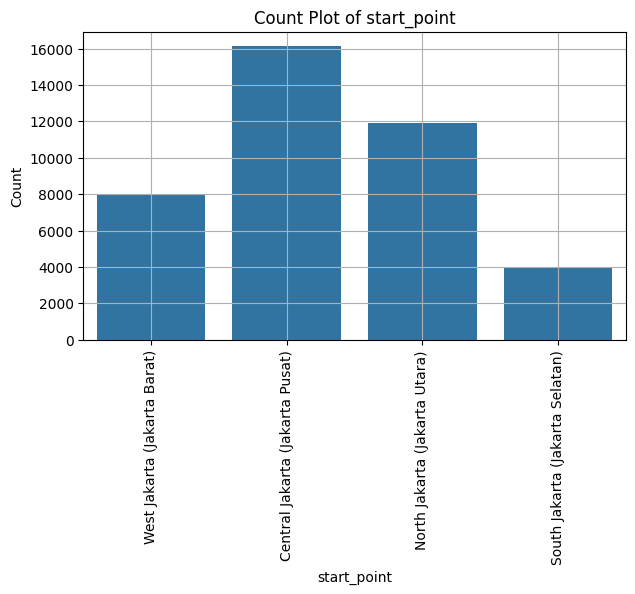

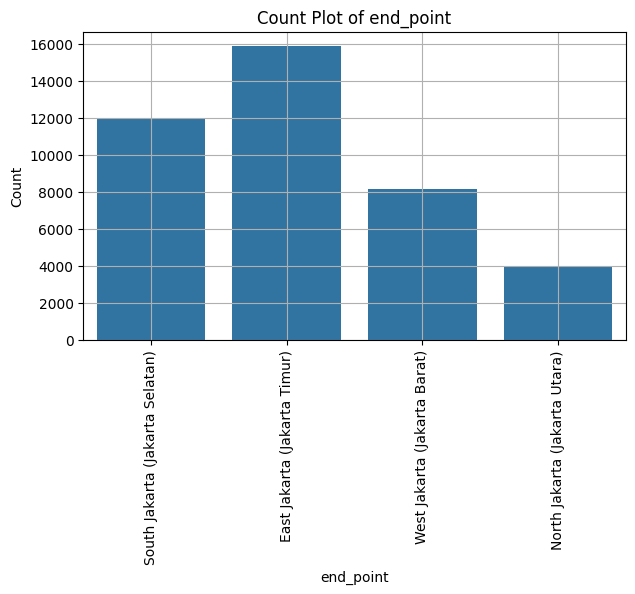

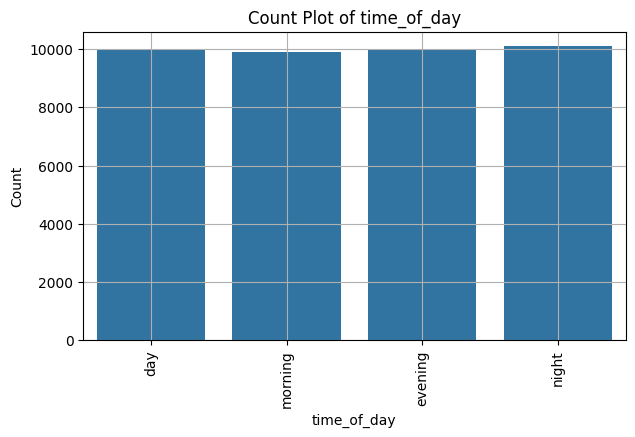

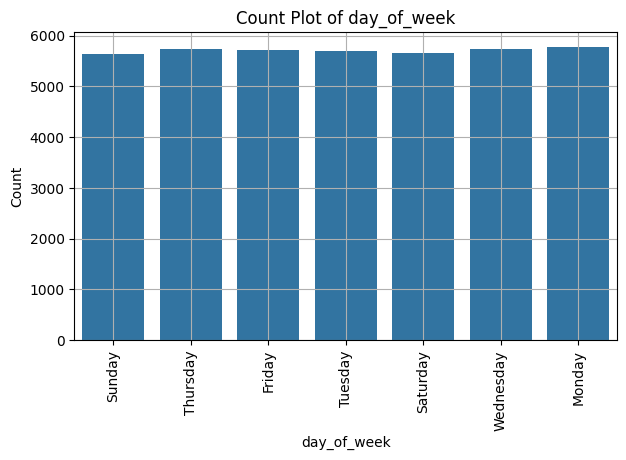

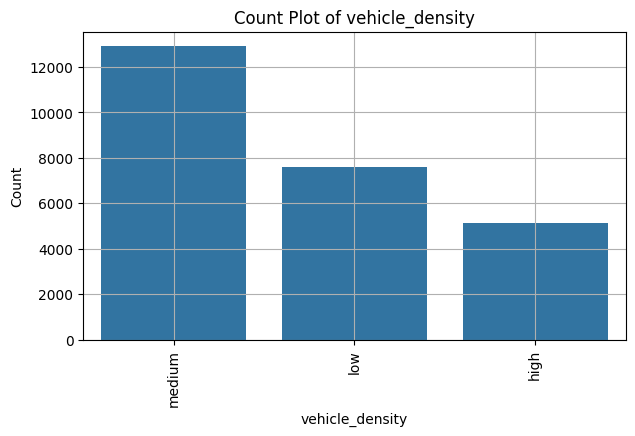

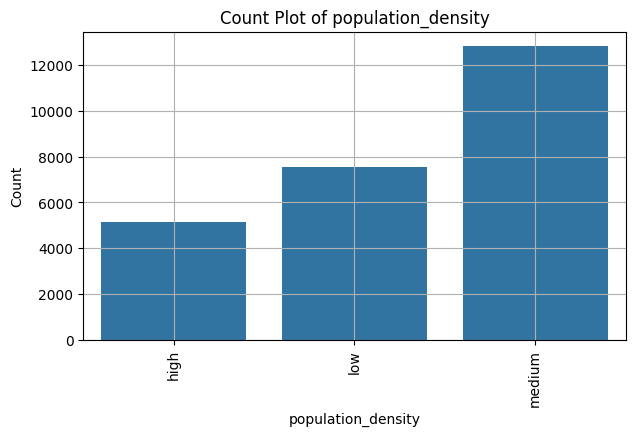

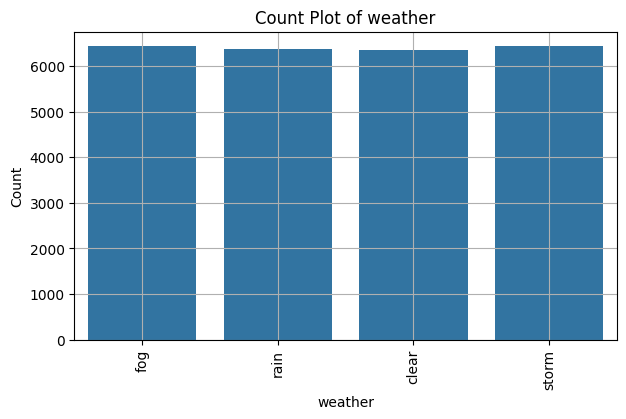

In [53]:
categorical_columns = df.select_dtypes(exclude=['number']).columns


for col in categorical_columns:
    plt.figure(figsize=(7, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.show()

## Corelation

In [54]:
df.corr(numeric_only=True)

,traffic_condition,event_count,is_holiday,public_transport_availability,historical_delay_factor,travel_time
traffic_condition,1.000000,0.001269,-0.005725,-0.008366,-0.005342,-0.001405
event_count,0.001269,1.000000,-0.008713,-0.001085,-0.015181,-0.009502
is_holiday,-0.005725,-0.008713,1.000000,-0.002084,-0.001013,-0.000366
public_transport_availability,-0.008366,-0.001085,-0.002084,1.000000,-0.002598,0.246958
historical_delay_factor,-0.005342,-0.015181,-0.001013,-0.002598,1.000000,0.052816
travel_time,-0.001405,-0.009502,-0.000366,0.246958,0.052816,1.000000


# Data Preprocessing

## Handling Missing Value

In [55]:
target_cols = ['vehicle_density', 'weather', 'population_density']


for col in target_cols:
    df[col] = df.groupby('day_of_week')[col].transform(
        lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
    )


In [56]:

target_cols = ['vehicle_density', 'weather', 'population_density']

for col in target_cols:
    df2[col] = df2.groupby('day_of_week')[col].transform(
        lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
    )


In [57]:
from sklearn.impute import KNNImputer


fitur_kategori = ['vehicle_density', 'weather', 'population_density']
target = 'traffic_condition'


data_subset = df[fitur_kategori + [target]].copy()

encoder = OrdinalEncoder()
data_subset[fitur_kategori] = encoder.fit_transform(data_subset[fitur_kategori].astype(str))


imputer = KNNImputer(n_neighbors=3)
data_imputed = imputer.fit_transform(data_subset)


data_imputed_df = pd.DataFrame(data_imputed, columns=fitur_kategori + [target])

data_imputed_df[target] = data_imputed_df[target].round()

df[target] = data_imputed_df[target].values


In [58]:
from sklearn.impute import KNNImputer



fitur_kategori = ['vehicle_density', 'weather', 'population_density']
target = 'traffic_condition'

data_subset2 = df2[fitur_kategori + [target]].copy()

encoder = OrdinalEncoder()
data_subset2[fitur_kategori] = encoder.fit_transform(data_subset2[fitur_kategori].astype(str))

imputer = KNNImputer(n_neighbors=3)
data_imputed2 = imputer.fit_transform(data_subset2)


data_imputed_df2 = pd.DataFrame(data_imputed2, columns=fitur_kategori + [target])


data_imputed_df2[target] = data_imputed_df2[target].round()


df2[target] = data_imputed_df2[target].values


In [59]:
df.isnull().sum()

,0
start_point,0
end_point,0
time_of_day,0
day_of_week,0
traffic_condition,0
event_count,0
is_holiday,0
vehicle_density,0
population_density,0
weather,0


In [60]:
df2.isnull().sum()

,0
start_point,0
end_point,0
time_of_day,0
day_of_week,0
traffic_condition,0
event_count,0
is_holiday,0
vehicle_density,0
population_density,0
weather,0


## Feature Engineering

In [61]:
df['rute'] = df['start_point'] + " - " + df['end_point']
df2['rute'] = df2['start_point'] + " - " + df2['end_point']

In [62]:
df['density'] = df['vehicle_density'] + " - " + df['population_density']

In [63]:
df['is_holiday'] = df['is_holiday'].map({0: 'libur', 1: 'biasa'}).astype(str)
df['rute'] = df['start_point'] + " - " + df['end_point']

In [64]:
df['day_of_week'] = df['day_of_week'] + " - " + df['is_holiday'] + " - " + df['time_of_day']

In [65]:
df['event_delay'] = df['event_count'] * df['historical_delay_factor']
df['traffic_delay'] = df['traffic_condition'] * df['historical_delay_factor']


In [66]:
df['traffic_weather'] = df['traffic_condition'].astype(str) + "_" + df['weather'].astype(str)
df['public_transport_holiday'] = df['public_transport_availability'].astype(str) + "_" + df['time_of_day'].astype(str)

In [67]:
df['rute'] = df['day_of_week'] + " - " + df['rute']

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   start_point                    40000 non-null  object 
 1   end_point                      40000 non-null  object 
 2   time_of_day                    40000 non-null  object 
 3   day_of_week                    40000 non-null  object 
 4   traffic_condition              40000 non-null  float64
 5   event_count                    40000 non-null  int64  
 6   is_holiday                     40000 non-null  object 
 7   vehicle_density                40000 non-null  object 
 8   population_density             40000 non-null  object 
 9   weather                        40000 non-null  object 
 10  public_transport_availability  40000 non-null  int64  
 11  historical_delay_factor        40000 non-null  float64
 12  travel_time                    40000 non-null 

## Delete Columns

In [69]:
df.drop(['start_point','end_point','vehicle_density','is_holiday','weather','traffic_condition','population_density','event_count','historical_delay_factor'],axis = 1, inplace = True)



## Check for duplicate rows

In [70]:
print("Number of duplicate rows before dropping:", df.duplicated().sum())

Number of duplicate rows before dropping: 0


## Handling outliers

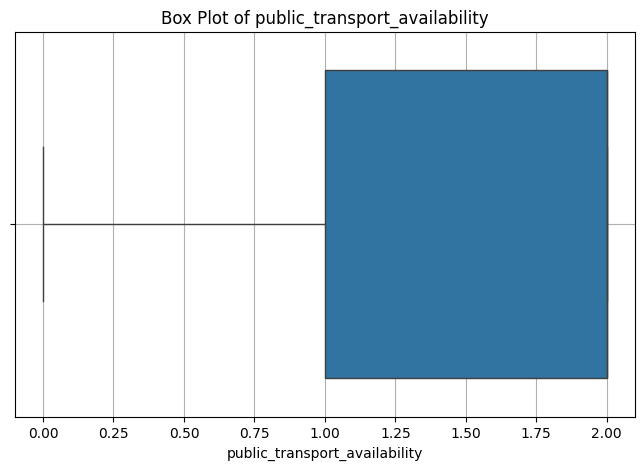

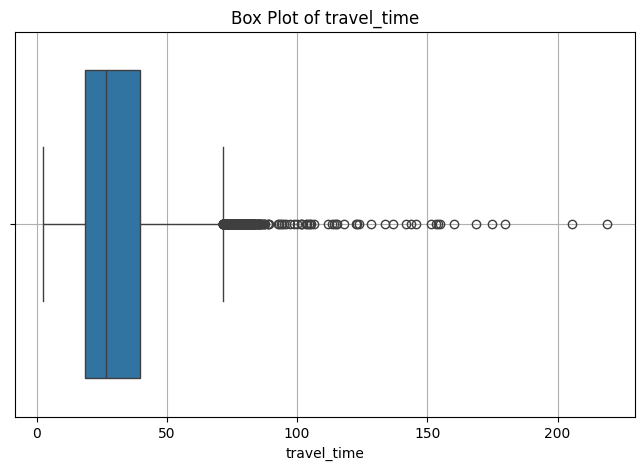

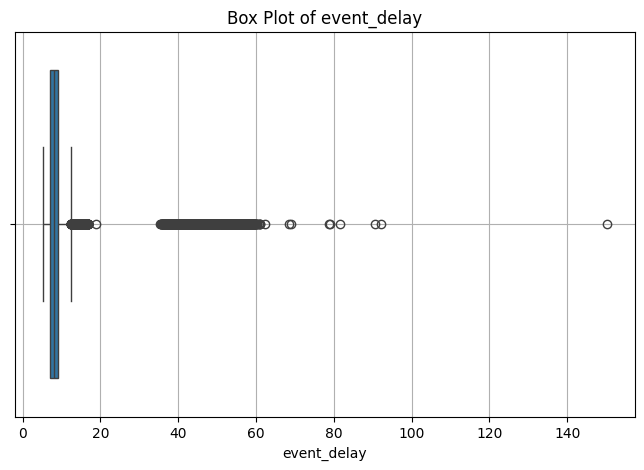

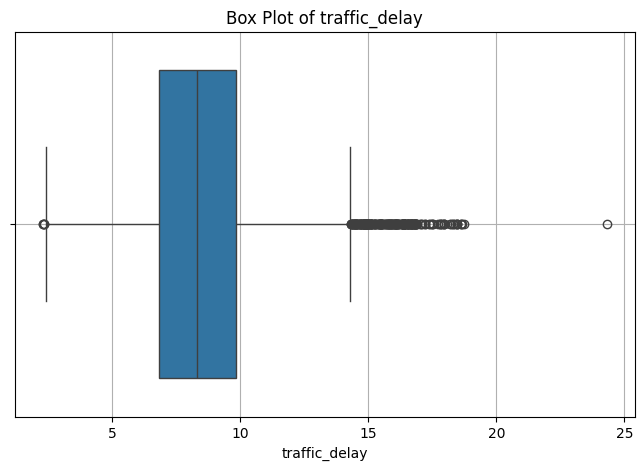

In [71]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns


def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.grid(True)
    plt.show()

In [72]:
numerical_cols_IQR = ['event_delay']

for col in numerical_cols_IQR:

    print(f"\n--- Statistik '{col}' SEBELUM IQR ---")
    print(df[col].describe())

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] > upper_bound, upper_bound,
                       np.where(df[col] < lower_bound, lower_bound, df[col]))


    print(f"\n--- Statistik '{col}' SETELAH IQR ---")
    print(df[col].describe())


--- Statistik 'event_delay' SEBELUM IQR ---
count    40000.000000
mean         8.774463
std          5.566846
min          5.250066
25%          6.965042
50%          7.990027
75%          9.155248
max        150.118138
Name: event_delay, dtype: float64

--- Statistik 'event_delay' SETELAH IQR ---
count    40000.000000
mean         8.136879
std          1.583378
min          5.250066
25%          6.965042
50%          7.990027
75%          9.155248
max         12.440557
Name: event_delay, dtype: float64


## Split Data

In [73]:
df.dropna(subset=['travel_time'], inplace=True)
X = df.drop('travel_time', axis=1)
y = df['travel_time']

print(f"Bentuk X: {X.shape}, Bentuk y: {y.shape}")
print("-" * 50)

# --- 3. Split Data (Train/Test Split) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"Bentuk X_train: {X_train.shape}, X_test: {X_test.shape}")
print("-" * 50)

Bentuk X: (40000, 9), Bentuk y: (40000,)
--------------------------------------------------
Bentuk X_train: (32000, 9), X_test: (8000, 9)
--------------------------------------------------


## Encoding

In [74]:
columns_to_encode = [ 'density','traffic_weather']


custom_orders = {

    'density': ['low - low','low - medium','low - high','medium - low','medium - medium','medium - high','high - low','high - medium','high - high'],

    'traffic_weather': [
        '10.0_storm', '10.0_rain', '10.0_fog', '10.0_clear',
        '9.0_storm', '9.0_rain', '9.0_fog', '9.0_clear',
        '8.0_storm', '8.0_rain', '8.0_fog', '8.0_clear',
        '7.0_storm', '7.0_rain', '7.0_fog', '7.0_clear',
        '6.0_storm', '6.0_rain', '6.0_fog', '6.0_clear',
        '5.0_storm', '5.0_rain', '5.0_fog', '5.0_clear',
        '3.0_storm', '3.0_rain', '3.0_fog', '3.0_clear'
    ]

}




categories = [custom_orders[col] for col in columns_to_encode]

encoder = OrdinalEncoder(categories=categories)

X_train[columns_to_encode] = encoder.fit_transform(X_train[columns_to_encode])
X_test[columns_to_encode] = encoder.transform(X_test[columns_to_encode])




In [75]:
col_cat = ['time_of_day','rute','day_of_week','public_transport_holiday']
X_train_dummies = pd.get_dummies(X_train, columns=col_cat, drop_first=True)
X_test_dummies = pd.get_dummies(X_test, columns=col_cat, drop_first=True)



In [76]:
X_train_dummies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32000 entries, 14307 to 15795
Columns: 633 entries, public_transport_availability to public_transport_holiday_2_night
dtypes: bool(628), float64(4), int64(1)
memory usage: 20.6 MB


## Scaling

In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_dummies)
X_test_scaled = scaler.transform(X_test_dummies)


X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_dummies.columns, index=X_train_dummies.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_dummies.columns, index=X_test_dummies.index)


In [78]:
X_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32000 entries, 14307 to 15795
Columns: 633 entries, public_transport_availability to public_transport_holiday_2_night
dtypes: float64(633)
memory usage: 154.8 MB


# Modeling

# LR

In [79]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


y_pred_train = lr_model.predict(X_train_scaled)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
print(f"Mean Squared Error: {mse_train}")
print(f"R-squared: {r2_train}")




Mean Squared Error: 19.793684747845393
R-squared: 0.9130469452268607


# Evaluation

In [80]:
y_pred_test = lr_model.predict(X_test_scaled)
mse_lr = mean_squared_error(y_test, y_pred_test)
r2_lr = r2_score(y_test, y_pred_test)

print("Linear Regression Metrics")
print(f"Mean Squared Error: {mse_lr}")
print(f"R-squared: {r2_lr}")

Linear Regression Metrics
Mean Squared Error: 18.42638026122061
R-squared: 0.918352035481975


In [81]:
from sklearn.feature_selection import mutual_info_regression
mi_scores = mutual_info_regression(X_test_scaled, y_test, random_state=42)

# Masukkan ke DataFrame untuk melihat ranking
mi_series = pd.Series(mi_scores, index=X_test_scaled.columns)
mi_series = mi_series.sort_values(ascending=False)

# Tampilkan 20 fitur paling informatif
print("Top 20 fitur paling informatif:")
print(mi_series.head(30))

Top 20 fitur paling informatif:
public_transport_availability                                                                      0.070993
time_of_day_night                                                                                  0.051723
density                                                                                            0.044214
time_of_day_evening                                                                                0.035816
public_transport_holiday_2_evening                                                                 0.035006
public_transport_holiday_0_night                                                                   0.033616
public_transport_holiday_2_night                                                                   0.025374
event_delay                                                                                        0.022687
public_transport_holiday_1_night                                                                   0.021

In [82]:
print("\n--- Koefisien (Weights) Model Terbaik untuk Setiap Fitur ---")
if len(lr_model.coef_) == len(X_train_scaled.columns):
    coef_df = pd.DataFrame({
        'Feature': X_train_scaled.columns,
        'Coefficient': lr_model.coef_
    })

    print(coef_df.sort_values(by='Coefficient', key=abs, ascending=False))
else:
    print("Jumlah koefisien tidak cocok dengan jumlah fitur. Ada masalah!")

print("\nIntercept (bias):", lr_model.intercept_)
print("-" * 50)


--- Koefisien (Weights) Model Terbaik untuk Setiap Fitur ---
                                               Feature  Coefficient
61   rute_Friday - libur - evening - North Jakarta ...     1.795888
21   rute_Friday - biasa - evening - North Jakarta ...     1.762049
221  rute_Saturday - libur - evening - North Jakart...     1.627600
261  rute_Sunday - biasa - evening - North Jakarta ...     1.573674
71   rute_Friday - libur - morning - North Jakarta ...     1.489309
..                                                 ...          ...
604             day_of_week_Thursday - libur - morning     0.010037
574                   day_of_week_Monday - biasa - day    -0.008256
76   rute_Friday - libur - morning - West Jakarta (...     0.006183
599             day_of_week_Thursday - biasa - evening     0.004420
576               day_of_week_Monday - biasa - morning    -0.001543

[633 rows x 2 columns]

Intercept (bias): 30.397926493787594
--------------------------------------------------


In [85]:
print("\n--- Koefisien (Weights) Model Terbaik untuk Setiap Fitur ---")
if len(lr_model.coef_) == len(X_train_scaled.columns):
    coef_df = pd.DataFrame({
        'Feature': X_train_dummies.columns,
        'Coefficient': lr_model.coef_
    })

    print(coef_df.sort_values(by='Coefficient', key=abs, ascending=False))
else:
    print("Jumlah koefisien tidak cocok dengan jumlah fitur. Ada masalah!")

print("\nIntercept (bias):", lr_model.intercept_)
print("-" * 50)


--- Koefisien (Weights) Model Terbaik untuk Setiap Fitur ---
                                               Feature  Coefficient
61   rute_Friday - libur - evening - North Jakarta ...     1.795888
21   rute_Friday - biasa - evening - North Jakarta ...     1.762049
221  rute_Saturday - libur - evening - North Jakart...     1.627600
261  rute_Sunday - biasa - evening - North Jakarta ...     1.573674
71   rute_Friday - libur - morning - North Jakarta ...     1.489309
..                                                 ...          ...
604             day_of_week_Thursday - libur - morning     0.010037
574                   day_of_week_Monday - biasa - day    -0.008256
76   rute_Friday - libur - morning - West Jakarta (...     0.006183
599             day_of_week_Thursday - biasa - evening     0.004420
576               day_of_week_Monday - biasa - morning    -0.001543

[633 rows x 2 columns]

Intercept (bias): 30.397926493787594
--------------------------------------------------


<font color=green><h3><b>$\epsilon$. References:</b></h3></font>

<font color=green> Remember to cite your sources here! List resources that helped you with ideas and code ([articles/books](https://scholar.google.com/), StackOverflow, Wikipedia, etc.)

<font color=green><b>Student's answer:</b></font>

1. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
1. ...
1. ...

</font>